# Experiments

# Dependences

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from rec_engine.config import Params, create_params

from project_ecommerce import MODEL_PATH, PARAMS_PATH
from project_ecommerce.baseline import BASELINE_PATH
from project_ecommerce.exp_deep_layers import EXP_DL_PATH
from project_ecommerce.exp_resample import EXP_RS_PATH
from project_ecommerce.feature_selection import FS_PATH

# Set Seaborn style
sns.set_style('darkgrid')
sns.set_context('notebook')
sns.set_palette('colorblind')

# Parameters

In [3]:
# Generate configuration files from the `rec_engine` package
create_params(path = MODEL_PATH)


The following parameters are considered baseline or "vanilla," serving as a foundation for initial experimentation before fine-tuning through hyperparameter optimization.

Some this parameters were inspired from [Tensorflow Tutorials](https://www.tensorflow.org/recommenders/examples/quickstart) and from experimentation behind the scenes.

In [4]:
# Parameters definition filled in the `params.json` file
params = {
    "logs_path": "",
    "target": "score",
    "batch_size": 64,
    "seed": 42,
    "tower": {
        "query": [
            "time",
            "cat-user_id",
            "cat-channel",
            "cat-device_type",
            "int-hour",
            "int-day_of_week",
            "text-query_text",
            # Create sequential features related to the last 5 products the user clicked on,
            # given by `product_id` and their corresponding categories, given by `category_name`.
            "seq-seq_product_id",
            "seq-seq_category_name",
            "score",
            ],
        "candidate": [
            "cat-product_id",
            "cat-category_name",
            "cat-merchant_name",
            "cat-merchant_city",
            "cat-merchant_state",
            "cat-merchant_region",
            "int-free_shipping",
            "int-is_sold_out",
            "int-editor_pick",
            "int-on_sale",
            "text-product_name",
            "disc-sales_last_week",
            "disc-sales_last_month",
            "disc-sales_last_year",
            "disc-price_in_cents",
            "disc-reviews",
            "norm-sales_last_week",
            "norm-sales_last_month",
            "norm-sales_last_year",
            "norm-price_in_cents",
            "norm-reviews",
        ]
    },
    "callbacks": {
        "early_stopping": {
            "patience": 3,
            "start_from_epoch": 5,
            "delta_retrieval": 0.01,
            "delta_rating": 0.01,
            # I"ll focus on top 50 because is unlikely a user will show more than 50 products
            "retrieval_metric": "val_factorized_top_k/top_50_categorical_accuracy",
            "rating_metric": "val_root_mean_squared_error"
        },
        "lr_schedule": {
            "monitor": "val_total_loss",
            "factor": 0.1,
            "patience": 1,
            "mode": "min",
            "min_delta": 10,
            "cooldown": 3,
            "min_lr": 1e-5
        }
    },
    # Baseline Model Hyperparameters
    "model": {
        "max_epochs": 50,
        "initial_learning_rate": 0.1,
        # embedding weight shared among all features where emb_size = (log2(input_dim) + 1) * emb_weigh
        "emb_weight": 6,
        # note that this model doesn"t have deep layers defined, only a dense layer to ensure same output size among the towers
        "query_layers": [16],
        "candidate_layers": [16],
        # rating model need one unit as output for regression
        "rating_layers": [128, 64, 1],
        "dropout": 0.1,
        # disable cross layer to keep it simple
        "cross_layer": False,
        "optimizer": "Adagrad"
    }
}

The current dataset has insufficient clicks per user to establish a reliable sequential feature, as only slightly more than 20% of users have more than one click. This limitation is primarily due to the data covering only a single week of user interactions. Nonetheless, I will proceed with creating sequential features, as these are expected to become more valuable when more extensive interaction data becomes available in the future.

Dump parameters for experiments

In [5]:
with open(PARAMS_PATH, "w") as f:
    f.write(Params(**params).model_dump_json(indent=4))

# Experiments

## Deep Retrieval Experiment
Test if it is worth to use deep layers in my retrieval model given the available data.

The following command runs the deep retrieval experiment:

`uv run -m project_ecommerce.exp_deep_layers '[[32], [64, 32], [128, 64, 32]]'`  

Note that this experiment can be parallelized by running it in different terminal instances and combining the results.  

This experiment uses cross-validation under the hood so sequential features will be dropped to avoid data leakage.

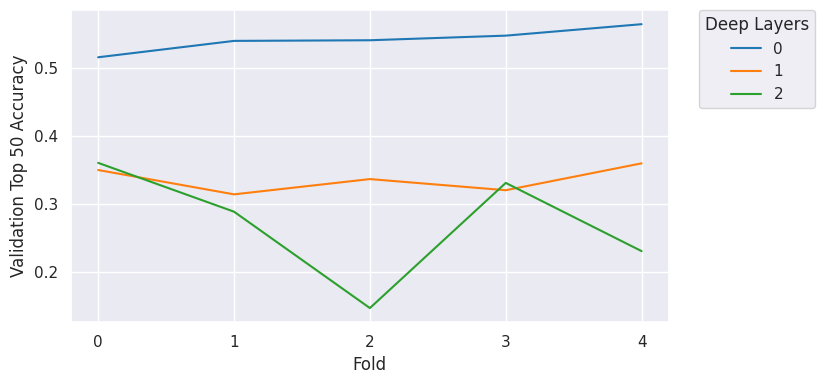

In [6]:
results_df = pd.read_csv(EXP_DL_PATH / "exp_dl-20250725-222328.csv")

def deep_ret_plot(results: pd.DataFrame):
    fig = plt.figure(figsize=(10, 4))

    palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    # Plot the retrieval metric against folds
    sns.lineplot(
        x="fold",
        y="val_factorized_top_k/top_50_categorical_accuracy",
        hue="n_layers",
        data=results,
        palette= palette
    )
    plt.xlabel("Fold")
    plt.ylabel("Validation Top 50 Accuracy")
    plt.xticks(range(0, 5))
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0., title="Deep Layers")
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space on the right for the legend
    plt.show()

deep_ret_plot(results_df)

Note we are focusing solely on analyzing the retrieval metrics, as the deep layers in this context impact only the retrieval model.

Based on the results, the retrieval accuracy decreases when deeper layers are added to both towers of the model. Also, the accuracy variance increased along the folds possibly indicating overfitting. Therefore, I will exclude deep layers from the current implementation to maintain performance. However, these deeper layers will be highly beneficial and strongly recommended as the dataset size increases, allowing the model to better leverage its capacity to learn more complex patterns.

## Baseline Model
The model selected to perform this analysis will be a baseline model that is as simple as possible to avoid overfitting, but complex enough that it doesn't fall into underfitting. Therefore, I will have disabled the cross layer and the deep layers in the retrieval model (only use one output layer to have the same output size in each tower).

Note I can't use KFold CV because the sequential features will lead to data leakage. I will use a simple train/validation split instead.

The following command train the baseline model:  

`uv run -m project_ecommerce.baseline`

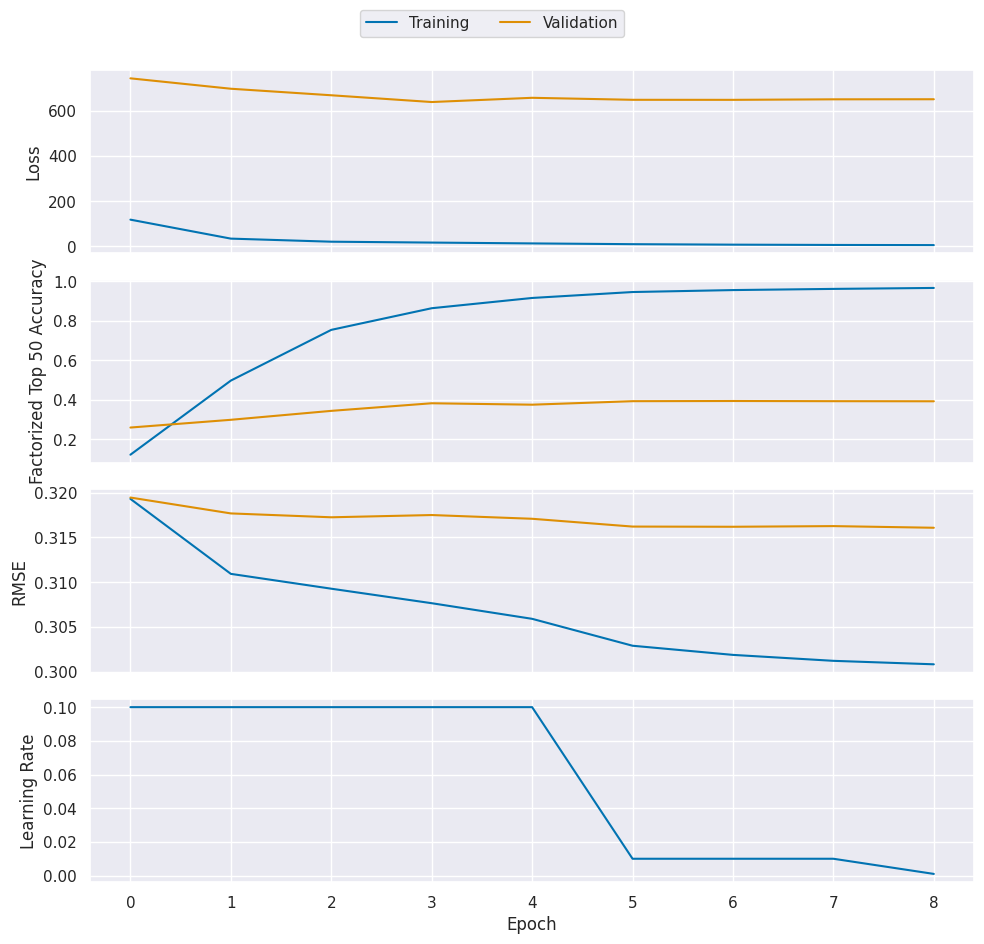

In [7]:
results_df = pd.read_csv(BASELINE_PATH / "baseline-20250725-150746.csv")

def baseline_analysis(history: pd.DataFrame):
    """
    Function to plot generalization curves.
    """
    fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)  # Adjusted figsize for better layout

    # Plot for total loss and validation loss
    history["total_loss"].plot(ax=ax[0], label="Training")
    history["val_total_loss"].plot(ax=ax[0], label="Validation")
    ax[0].set_ylabel("Loss")

    # Plot for accuracy
    history[["factorized_top_k/top_50_categorical_accuracy", "val_factorized_top_k/top_50_categorical_accuracy"]].plot(ax=ax[1], legend=False)
    ax[1].set_ylabel("Factorized Top 50 Accuracy")

    # Plot for RMSE
    history[["root_mean_squared_error", "val_root_mean_squared_error"]].plot(ax=ax[2], legend=False)
    ax[2].set_ylabel("RMSE")

    # Plot learning rate schedule
    history["lr"].plot(ax=ax[3], legend = False)
    ax[3].set_xlabel("Epoch")
    ax[3].set_ylabel("Learning Rate")

    lines, labels = ax[0].get_legend_handles_labels()
    # Place the legend at the lower center
    fig.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=4)

    for a in ax:
        a.set_xticks(range(len(history)))
    # Adjust layout to make space for the legend
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

baseline_analysis(results_df)

This baseline model obtains:  
- Retrieval metric: `factorized_top_k/top_50_categorical_accuracy` ~= 0.4
- Ranking metric: `root_mean_squared_error` ~= 0.32

It is important to note that the RMSE does not show any improvement throughout the training process, even it's barely equal to the standard deviation of the target variable, meaning that the model is predicting the mean all the time. This suggests that the ranking model is struggling to learn how to accurately predict the product scores based on user feedback, which we defined as our target variable. The underlying issue appears to be the sparsity of user feedback data, which limits the model's ability to learn meaningful patterns.

To address this challenge, implementing resampling techniques may enhance the model's performance by providing a more balanced representation of the data. These techniques can help mitigate the effects of sparse feedback and improve the model's ability to learn from the available data.

## Resampling
After experimenting with the model, I observed that the **RMSE** metric along the *rating model* showed no improvement. Given the sparsity of my dataset, I plan to address this issue by applying resampling techniques to balance the data, specifically focusing on the `score` feature, which serves as the target variable.

The `score` feature exhibits significant skewness, which could be contributing to the model's poor performance. To mitigate this, I will utilize the *ImbalancedLearningRegression* package, implementing various resampling strategies. The goal is to redistribute the data more evenly across the range of `score` values, thus reducing the imbalance and potentially enhancing the model’s predictive accuracy.

By balancing the dataset through resampling, I aim to improve the RMSE metric and overall performance of the ranking task.

Reference:  
*Wu, W., Kunz, N., & Branco, P. (2022, September). ImbalancedLearningRegression-A Python Package to Tackle the Imbalanced Regression Problem. In Joint European Conference on Machine Learning and Knowledge Discovery in Databases (pp. 645-648). Cham: Springer Nature Switzerland.*

Resampling techniques don't allow sequential features, so they are removed.  
The following command runs the resampling experiment:  

`uv run -m project_ecommerce.exp_resample`

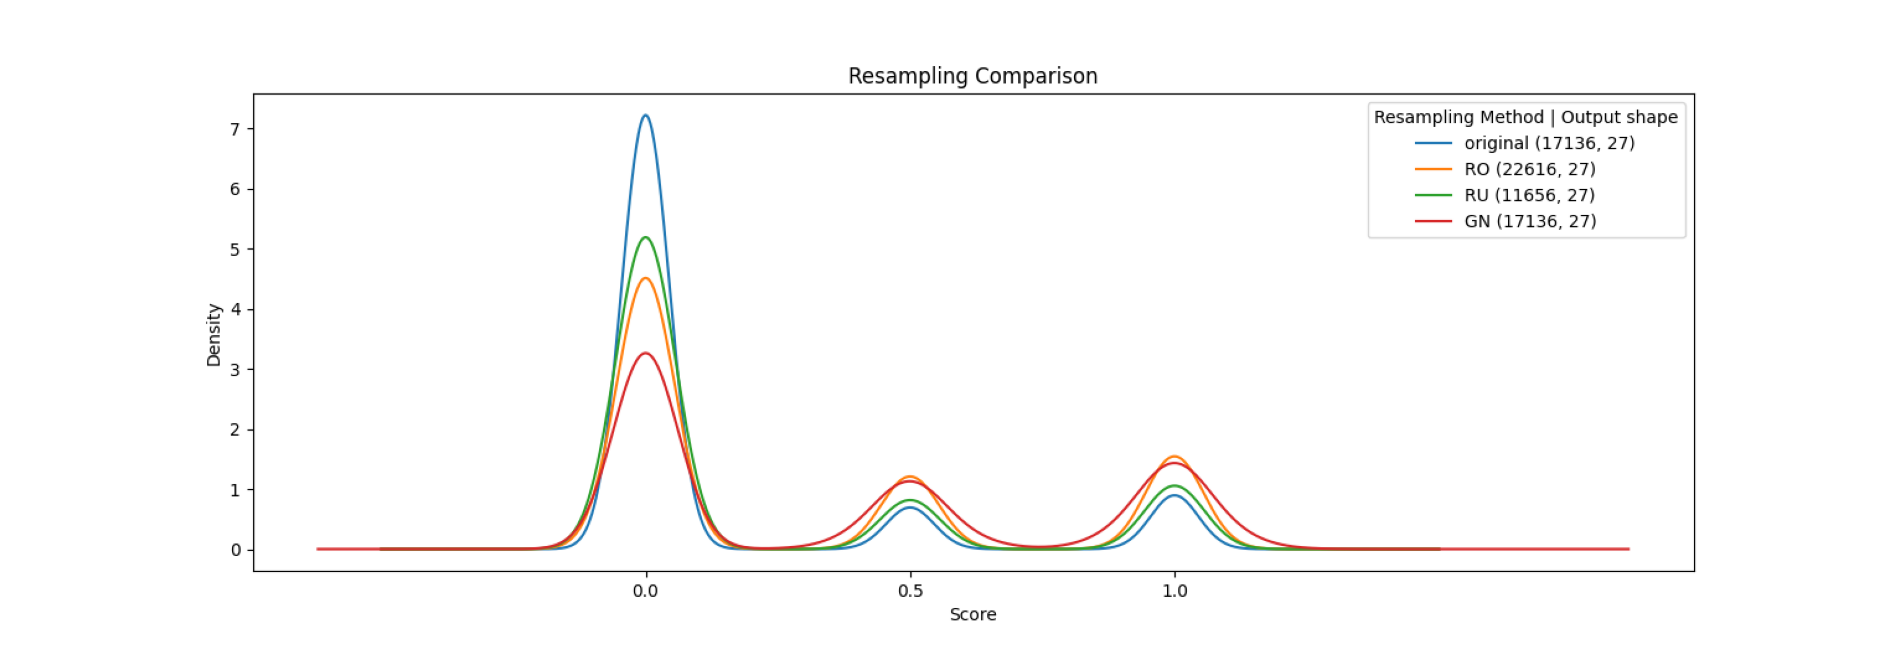

In [8]:
img = plt.imread(EXP_RS_PATH / "resampling_comparison.png")
plt.figure(figsize=(12, 10), dpi=200)
plt.imshow(img)
plt.axis('off')
plt.show()

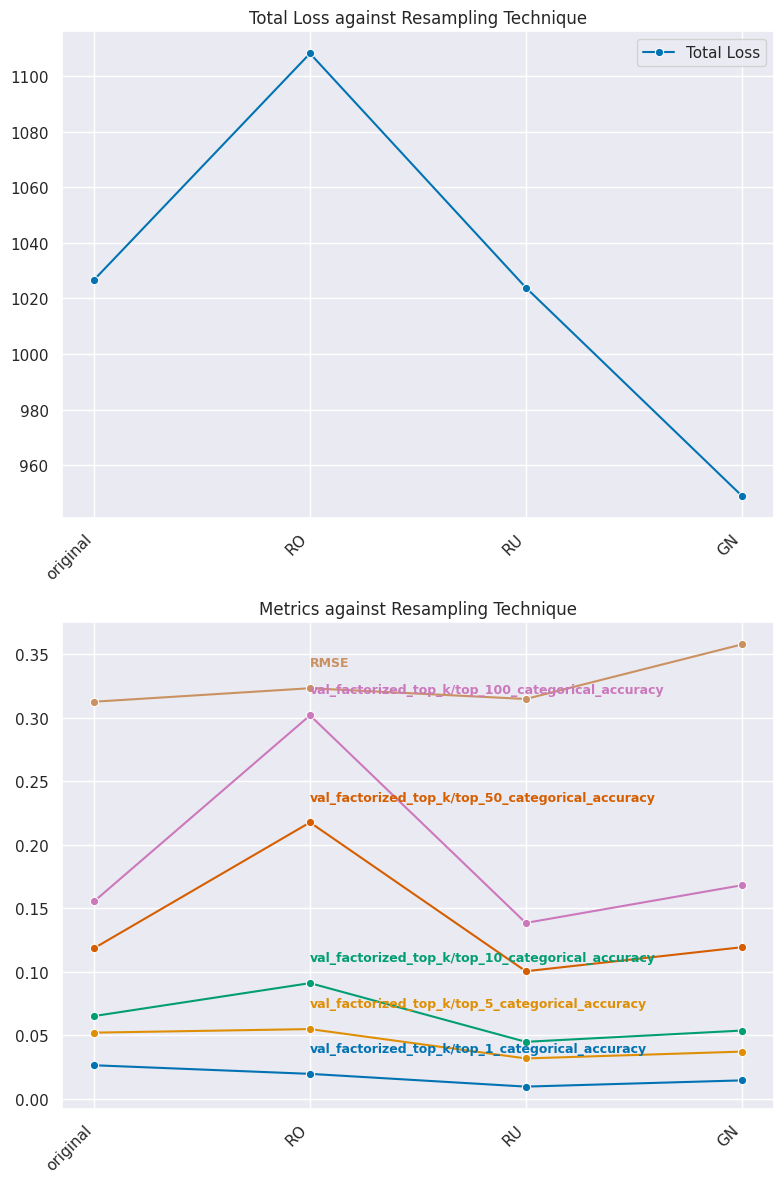

In [10]:
results_df = pd.read_csv(EXP_RS_PATH / "exp_res-20250725-223317.csv")

def resampling_plot(results: pd.DataFrame):
    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 12))

    # Total Loss against Batch Size Plot
    sns.lineplot(data=results, x="name", y="val_total_loss", marker="o", label="Total Loss", ax=axes[0])

    # Factorized Top K Metrics against Batch Size Plot
    retrieval_metrics = [c for c in results.columns if c.startswith("val_factorized")]
    for metric in retrieval_metrics:
        sns.lineplot(data=results, x="name", y=metric, marker="o", label=metric, ax=axes[1])

    # RMSE against Batch Size Plot
    sns.lineplot(data=results, x="name", y="val_root_mean_squared_error", marker="o", label="RMSE", ax=axes[1])

    # Set titles
    axes[0].set_title("Total Loss against Resampling Technique")
    axes[1].set_title("Metrics against Resampling Technique")

    # Set labels and ticks
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticks(results["name"])
        ax.set_xticklabels(results["name"], rotation=45, ha="right")

    # Place labels directly over the lines
    for line, label in zip(plt.gca().get_lines(), retrieval_metrics + ["RMSE"]):
        x = line.get_xdata()[1]
        y = line.get_ydata()[1] + 0.02

        plt.text(x, y, label, color=line.get_color(), fontweight="bold", va="center", fontsize= 9)

    plt.legend().set_visible(False)
    plt.tight_layout()
    plt.show()

resampling_plot(results_df)

The resampling techniques applied did not result in a significant improvement along the RMSE metric over the original dataset. The ranking model's performance remained largely unchanged, suggesting that the model may be limited by the inherent sparsity and lack of sufficient data. This could indicate that the model has already extracted most of the learnable patterns from the data, and further improvements may require either more comprehensive data or a different modeling approach.

## Forward Feature Selection

To identify the most impactful features while minimizing noise, I will gradually add features to the model, carefully logging the resulting metrics after each addition. I will start with a baseline which follows a standard matrix factorization model. User feature `user_id` and product feature `product_id` are the minimum required variables to develop a matrix factorization model. I will be adding side features looking for improvements.  

The sequence in which features are added is crucial, as it can significantly influence the features selected by the model. Running the process in a different order may lead to a different subset of features being chosen. This is due to the potential collinearity between features and the fact that adding a new feature doesn't always improve model performance—in some cases, it can even degrade accuracy.

The following command runs the feature selection process:  

`uv run -m project_ecommerce.feature_selection`

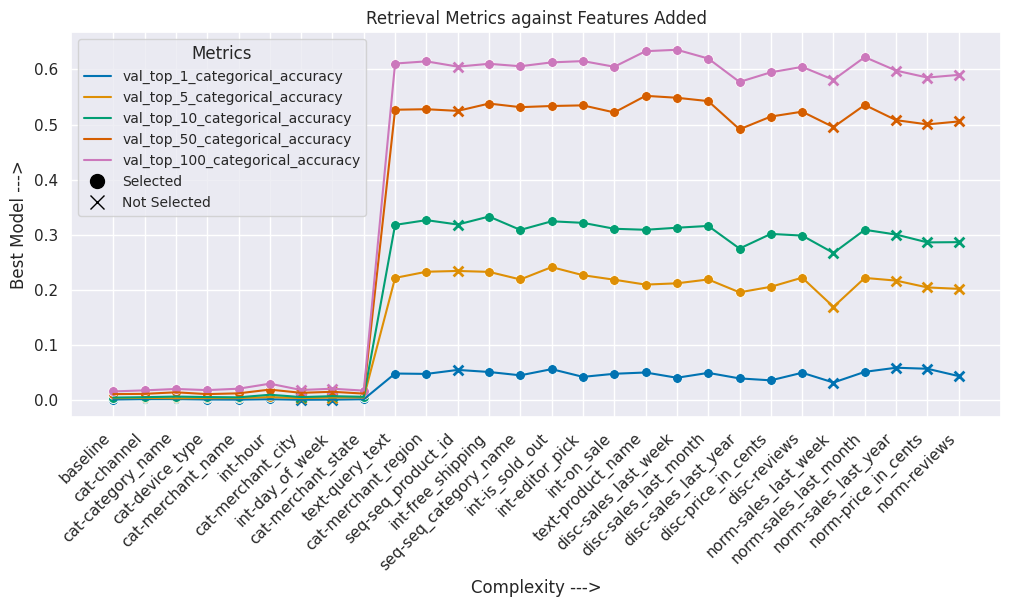

In [12]:
results_df = pd.read_csv(FS_PATH / "fs-20250726-235509.csv")

def fs_plot(results: pd.DataFrame, values: list):
    # Plot Retrieval Metrics against Features Added
    fig = plt.figure(figsize=(12, 5))

    for value in values:
        line_plot = sns.lineplot(data=results, x="feature", y=value, label= value, markers=True)
        line_color = line_plot.get_lines()[-1].get_color()
        sns.scatterplot(data=results[results["selected"]], x="feature", y=value, marker="o", color=line_color, s=50)
        sns.scatterplot(data=results[~results["selected"]], x="feature", y=value, marker="x", color=line_color, s=50, linewidth=2)

    legend_elements = [
            Line2D([0], [0], color="black", marker="o", markersize=10,
                              label="Selected", linestyle="None", linewidth=2),
        Line2D([0], [0], color="black", marker="x", markersize=10,
                              label="Not Selected", linestyle="None", linewidth=2)
    ]

    # Add the default legend for lines, and then the manual marker legend
    plt.legend(
        title="Metrics",
        handles=plt.gca().get_legend().legend_handles + legend_elements,
        fontsize= 10
    )
    plt.xticks(rotation=45, ha= "right")
    plt.xlabel("Complexity --->")
    return fig

results_df.columns = [col.replace("val_factorized_top_k/", "val_") for col in results_df.columns]
plot = fs_plot(results_df, values = [c for c in results_df.columns if c.startswith("val_top")])
plt.title("Retrieval Metrics against Features Added")
plt.ylabel("Best Model --->")
plt.show()

Notice the addition of `query_text` feature increases enormously the retrieval accuracy. This is obvious since the query text is the keyword that the user is searching for, and it is expected to have a strong correlation with the products that the user will click on.  

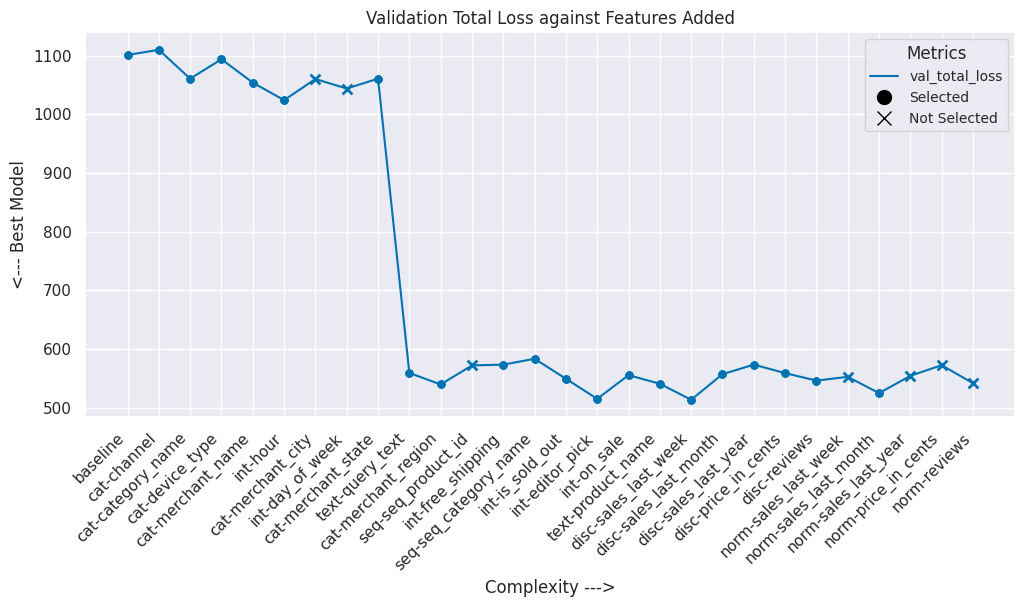

In [13]:
plot = fs_plot(results_df, values = ["val_total_loss"])

plt.title("Validation Total Loss against Features Added")
plt.ylabel("<--- Best Model")
plt.show()

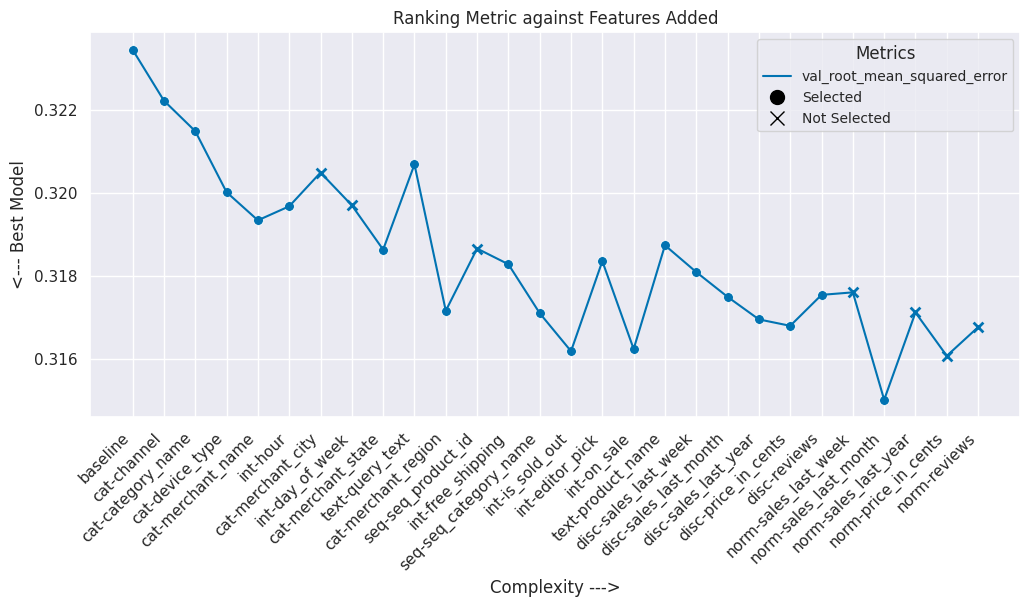

In [14]:
plot = fs_plot(results_df, values = ["val_root_mean_squared_error"])

plt.title("Ranking Metric against Features Added")
plt.ylabel("<--- Best Model")
plt.show()

Based on the results obtained, the following features demonstrate a decrease in accuracy when included in the model:

In [15]:
not_selected_features = results_df[results_df["selected"] == False]["feature"].tolist()
not_selected_features

['cat-merchant_city',
 'int-day_of_week',
 'seq-seq_product_id',
 'norm-sales_last_week',
 'norm-sales_last_year',
 'norm-price_in_cents',
 'norm-reviews']

Sequential features, `seq_product_id` and `seq_category_name`, show limited utility, as only 20% of users have recorded multiple clicks. Thus, including this sequential data as a feature does not provide significant value. By excluding sequential features, I am now able to work with shuffled versions of the training and validation datasets, which may further simplify the model.

In [16]:
params["tower"]["query"] = [f for f in params["tower"]["query"] if f not in not_selected_features]
params["tower"]["candidate"] = [f for f in params["tower"]["candidate"] if f not in not_selected_features]
params["tower"]

{'query': ['time',
  'cat-user_id',
  'cat-channel',
  'cat-device_type',
  'int-hour',
  'text-query_text',
  'seq-seq_category_name',
  'score'],
 'candidate': ['cat-product_id',
  'cat-category_name',
  'cat-merchant_name',
  'cat-merchant_state',
  'cat-merchant_region',
  'int-free_shipping',
  'int-is_sold_out',
  'int-editor_pick',
  'int-on_sale',
  'text-product_name',
  'disc-sales_last_week',
  'disc-sales_last_month',
  'disc-sales_last_year',
  'disc-price_in_cents',
  'disc-reviews',
  'norm-sales_last_month']}

In [17]:
with open(PARAMS_PATH, "w") as f:
    f.write(Params(**params).model_dump_json(indent=4))